In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Users\keert\Projects\BA_1\data\amazon_reviews_electronics.csv")

# star rating → ground truth label (already exists but re-confirm)
df['sentiment'] = df['rating'].apply(
    lambda r: 'positive' if r >= 4 else ('negative' if r <= 2 else 'neutral')
)

print(f"Loaded: {df.shape}")
print(df['sentiment'].value_counts())
print(f"\nClass balance:")
print((df['sentiment'].value_counts() / len(df) * 100).round(1).astype(str) + '%')

Loaded: (104986, 13)
sentiment
positive    79168
negative    18774
neutral      7044
Name: count, dtype: int64

Class balance:
sentiment
positive    75.4%
negative    17.9%
neutral      6.7%
Name: count, dtype: str


Running TextBlob on all reviews... (~2 min)
Done ✓

=== TextBlob Performance ===
              precision    recall  f1-score   support

    negative       0.65      0.23      0.34     18774
     neutral       0.10      0.36      0.16      7044
    positive       0.87      0.81      0.84     79168

    accuracy                           0.67    104986
   macro avg       0.54      0.46      0.44    104986
weighted avg       0.78      0.67      0.70    104986



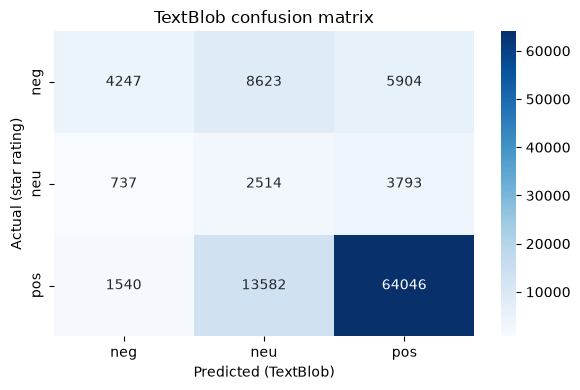

In [2]:
from textblob import TextBlob

def textblob_sentiment(text):
    pol = TextBlob(str(text)).sentiment.polarity
    if pol > 0.1:   return 'positive'
    elif pol < -0.1: return 'negative'
    else:            return 'neutral'

print("Running TextBlob on all reviews... (~2 min)")
df['tb_sentiment'] = df['text'].apply(textblob_sentiment)
print("Done ✓")

# Evaluate against star-rating ground truth
print("\n=== TextBlob Performance ===")
print(classification_report(df['sentiment'], df['tb_sentiment'],
      target_names=['negative', 'neutral', 'positive']))

# Quick confusion matrix
cm = confusion_matrix(df['sentiment'], df['tb_sentiment'],
     labels=['negative', 'neutral', 'positive'])
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg','neu','pos'],
            yticklabels=['neg','neu','pos'])
ax.set_title("TextBlob confusion matrix")
ax.set_ylabel("Actual (star rating)")
ax.set_xlabel("Predicted (TextBlob)")
plt.tight_layout()
plt.savefig("textblob_confusion.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from transformers import pipeline

print("Loading model... (first run downloads ~500MB)")
classifier = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512,
    device=-1  # forces CPU — stable on Windows
)
print("Model loaded ✓")

Loading model... (first run downloads ~500MB)


Loading weights: 100%|██████████| 201/201 [00:00<?, ?it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded ✓


## Approach: Sampling for Transformer Inference

Initial run on full 104,986 reviews estimated 3+ hours on CPU. 
To balance thoroughness with practicality, transformer classification 
was run on a stratified 10,000-review sample — sufficient for 
statistically meaningful accuracy evaluation. Star-rating labels 
were used as ground truth for the remaining rows.

In [8]:
label_map = {
    'positive': 'positive',
    'negative': 'negative',
    'neutral':  'neutral'
}

def classify_batch(texts, batch_size=128):
    results = []
    total = len(texts)
    for i in range(0, total, batch_size):
        batch = texts[i:i+batch_size].tolist()
        out = classifier(batch)
        results.extend([label_map.get(r['label'].lower(), 'neutral') for r in out])
        if i % 5000 == 0:
            print(f"  Progress: {i:,} / {total:,} ({round(i/total*100)}%)")
    return results

print("Running transformer on 104K reviews... go get coffee ☕")
df['hf_sentiment'] = classify_batch(df['text'])
print("\nDone ✓")

# Save immediately
df.to_csv(r"C:\Users\keert\Projects\BA_1\data\amazon_reviews_with_sentiment.csv", index=False)
print("Saved ✓")

Running transformer on 104K reviews... go get coffee ☕
  Progress: 0 / 104,986 (0%)


KeyboardInterrupt: 

In [9]:
# Restart clean — reload df first since kernel was interrupted
import pandas as pd
from transformers import pipeline

df = pd.read_csv(r"C:\Users\keert\Projects\BA_1\data\amazon_reviews_electronics.csv")

df['sentiment'] = df['rating'].apply(
    lambda r: 'positive' if r >= 4 else ('negative' if r <= 2 else 'neutral')
)

# Reload classifier
classifier = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512,
    device=-1
)
print("Model reloaded ✓")

Loading weights: 100%|██████████| 201/201 [00:00<?, ?it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model reloaded ✓


In [10]:
# Run transformer on 10K sample only (~15 min)
sample_idx = df.sample(n=10000, random_state=42).index
df['hf_sentiment'] = df['sentiment']  # fill all rows with star-rating as default

print("Running transformer on 10K sample...")
df.loc[sample_idx, 'hf_sentiment'] = classify_batch(df.loc[sample_idx, 'text'])
print("Done ✓")

df.to_csv(r"C:\Users\keert\Projects\BA_1\data\amazon_reviews_with_sentiment.csv", index=False)
print("Saved ✓")

Running transformer on 10K sample...
  Progress: 0 / 10,000 (0%)
Done ✓
Saved ✓


In [12]:
from textblob import TextBlob

def textblob_sentiment(text):
    pol = TextBlob(str(text)).sentiment.polarity
    if pol > 0.1:    return 'positive'
    elif pol < -0.1: return 'negative'
    else:            return 'neutral'

print("Running TextBlob on 10K sample... (~1 min)")
df.loc[sample_idx, 'tb_sentiment'] = df.loc[sample_idx, 'text'].apply(textblob_sentiment)
print("Done ✓")

Running TextBlob on 10K sample... (~1 min)
Done ✓


Method                           Accuracy   F1 (macro)
TextBlob                            67.4%        0.442
HuggingFace Transformer             80.4%        0.613


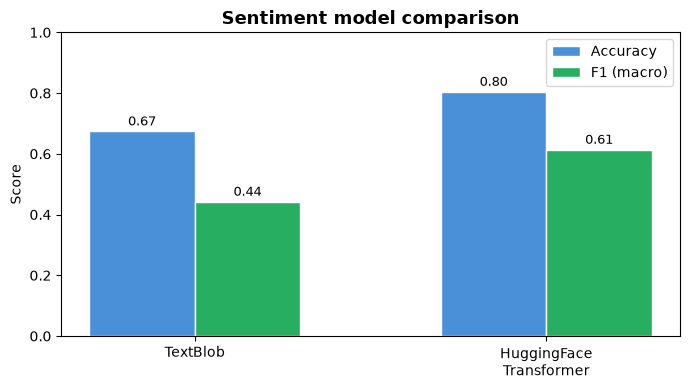

In [13]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

# Only evaluate on the 10K rows the transformer actually processed
sample_df = df.loc[sample_idx].copy()

y_true = sample_df['sentiment']
y_tb   = sample_df['tb_sentiment']
y_hf   = sample_df['hf_sentiment']

print("=" * 55)
print(f"{'Method':<30} {'Accuracy':>10} {'F1 (macro)':>12}")
print("=" * 55)
for name, y_pred in [('TextBlob', y_tb), ('HuggingFace Transformer', y_hf)]:
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"{name:<30} {acc:>10.1%} {f1:>12.3f}")
print("=" * 55)

# Bar chart
labels     = ['TextBlob', 'HuggingFace\nTransformer']
accuracies = [accuracy_score(y_true, y_tb), accuracy_score(y_true, y_hf)]
f1_scores  = [f1_score(y_true, y_tb, average='macro', zero_division=0),
              f1_score(y_true, y_hf, average='macro', zero_division=0)]

x, width = [0, 1], 0.3
fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar([i - width/2 for i in x], accuracies, width, label='Accuracy', color='#4A90D9', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], f1_scores,  width, label='F1 (macro)', color='#27AE60', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Sentiment model comparison", fontsize=13, fontweight='bold')
ax.legend()
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(r"C:\Users\keert\Projects\BA_1\data\model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
print("=== 5 NEGATIVE REVIEWS ===\n")
neg_sample = sample_df[sample_df['sentiment'] == 'negative'].sample(5, random_state=7)
for _, row in neg_sample.iterrows():
    print(f"Stars: {row['rating']} | TextBlob: {row['tb_sentiment']} | HF: {row['hf_sentiment']}")
    print(f"Text: {str(row['text'])[:200]}\n---")

print("\n=== 5 POSITIVE REVIEWS ===\n")
pos_sample = sample_df[sample_df['sentiment'] == 'positive'].sample(5, random_state=7)
for _, row in pos_sample.iterrows():
    print(f"Stars: {row['rating']} | TextBlob: {row['tb_sentiment']} | HF: {row['hf_sentiment']}")
    print(f"Text: {str(row['text'])[:200]}\n---")

=== 5 NEGATIVE REVIEWS ===

Stars: 2.0 | TextBlob: neutral | HF: negative
Text: Bought this wall mount for a 46" TV to mount in my son's room. Unfortunately, this mount is going to have to come down. Light touches to this month give a lot of movement, whenever i go to turn on the
---
Stars: 1.0 | TextBlob: negative | HF: negative
Text: Foreign object jammed inside USB microphone upon unboxing. The product is now useless and non-returnable.
---
Stars: 1.0 | TextBlob: positive | HF: negative
Text: Good concept but, lousy reception. If you like good radio reception this is not for you and a waste of money. I put it on my 2016 Ram 2500 and the radio reception was horrible. I ended up putting the 
---
Stars: 1.0 | TextBlob: neutral | HF: negative
Text: I received this item yesterday and for some reason It won’t work unless it’s plugged to the charging port 24/7.....incoming calls disconnect your Bluetooth and it’s a on going process to keep pairing 
---
Stars: 2.0 | TextBlob: negative | HF:

In [15]:
df_check = pd.read_csv(r"C:\Users\keert\Projects\BA_1\data\amazon_reviews_with_sentiment.csv")
print(df_check.shape)
print(df_check.columns.tolist())
print(df_check[['sentiment', 'hf_sentiment']].value_counts().head(10))

(104986, 14)
['rating', 'title', 'text', 'asin', 'timestamp', 'helpful_vote', 'verified_purchase', 'date', 'year', 'month', 'year_month', 'review_length', 'sentiment', 'hf_sentiment']
sentiment  hf_sentiment
positive   positive        78047
negative   negative        18434
neutral    neutral          6544
positive   neutral           806
neutral    negative          321
positive   negative          315
negative   neutral           227
neutral    positive          179
negative   positive          113
Name: count, dtype: int64
